# Computing and Visualizing Prime Numbers

## Number Theory Final Project

This notebook explores prime numbers through computation and visualization.
We'll implement the Sieve of Eratosthenes, verify the Prime Number Theorem
empirically, analyze prime gaps, and generate the Ulam spiral, which is all 
backed by a parallel C sieve engine that distributes work across processes 
and threads.

In [21]:
import sys
import os
sys.path.insert(0, os.getcwd())

import plot_primes as pp
import numpy as np
import matplotlib.pyplot as plt

## Generates primes using a C script

The C script implements a parallel sieve to generate a large amount of primes and saves it
into all_primes.csv and all_primes.npy

In [ ]:
def generate_primes(processes, threads, range_size, start):
    df = pp.load_prime_data(processes, threads, range_size, start)
    if df is not None:
        primes = np.array(df["prime"])
        print(f"Generated {len(primes):,} primes")
        return primes, df
    else:
        raise RuntimeError("Prime generation failed")

processes = 8
threads = 8
range_size = 1_000_000_000 # * number of processes
start = 1

generate_primes(processes, threads, range_size, start);

Cleaning up directory...
Directory cleaned succesfully
Compiling C program...
C program compliled succesfully...

Running prime finder with 8 processes, 8 threads, range 125000000, start 1...
C program ran successfully...

Generated 50,847,525 primes


Loads styles and primes from all_primes.npy

In [ ]:
# Styling
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'figure.figsize': (10, 8)
})

# Load primes
primes = np.load("all_primes.npy")
gaps = np.diff(primes)

print(f"Loaded {len(primes):,} primes from {primes[0]:,} to {primes[-1]:,}")

Loaded 50,847,525 primes from 2 to 999,999,937


## Shows how the sieve of Eratosthenes visually

Set the limit value and it will show how each prime removes composite numbers until only primes remain

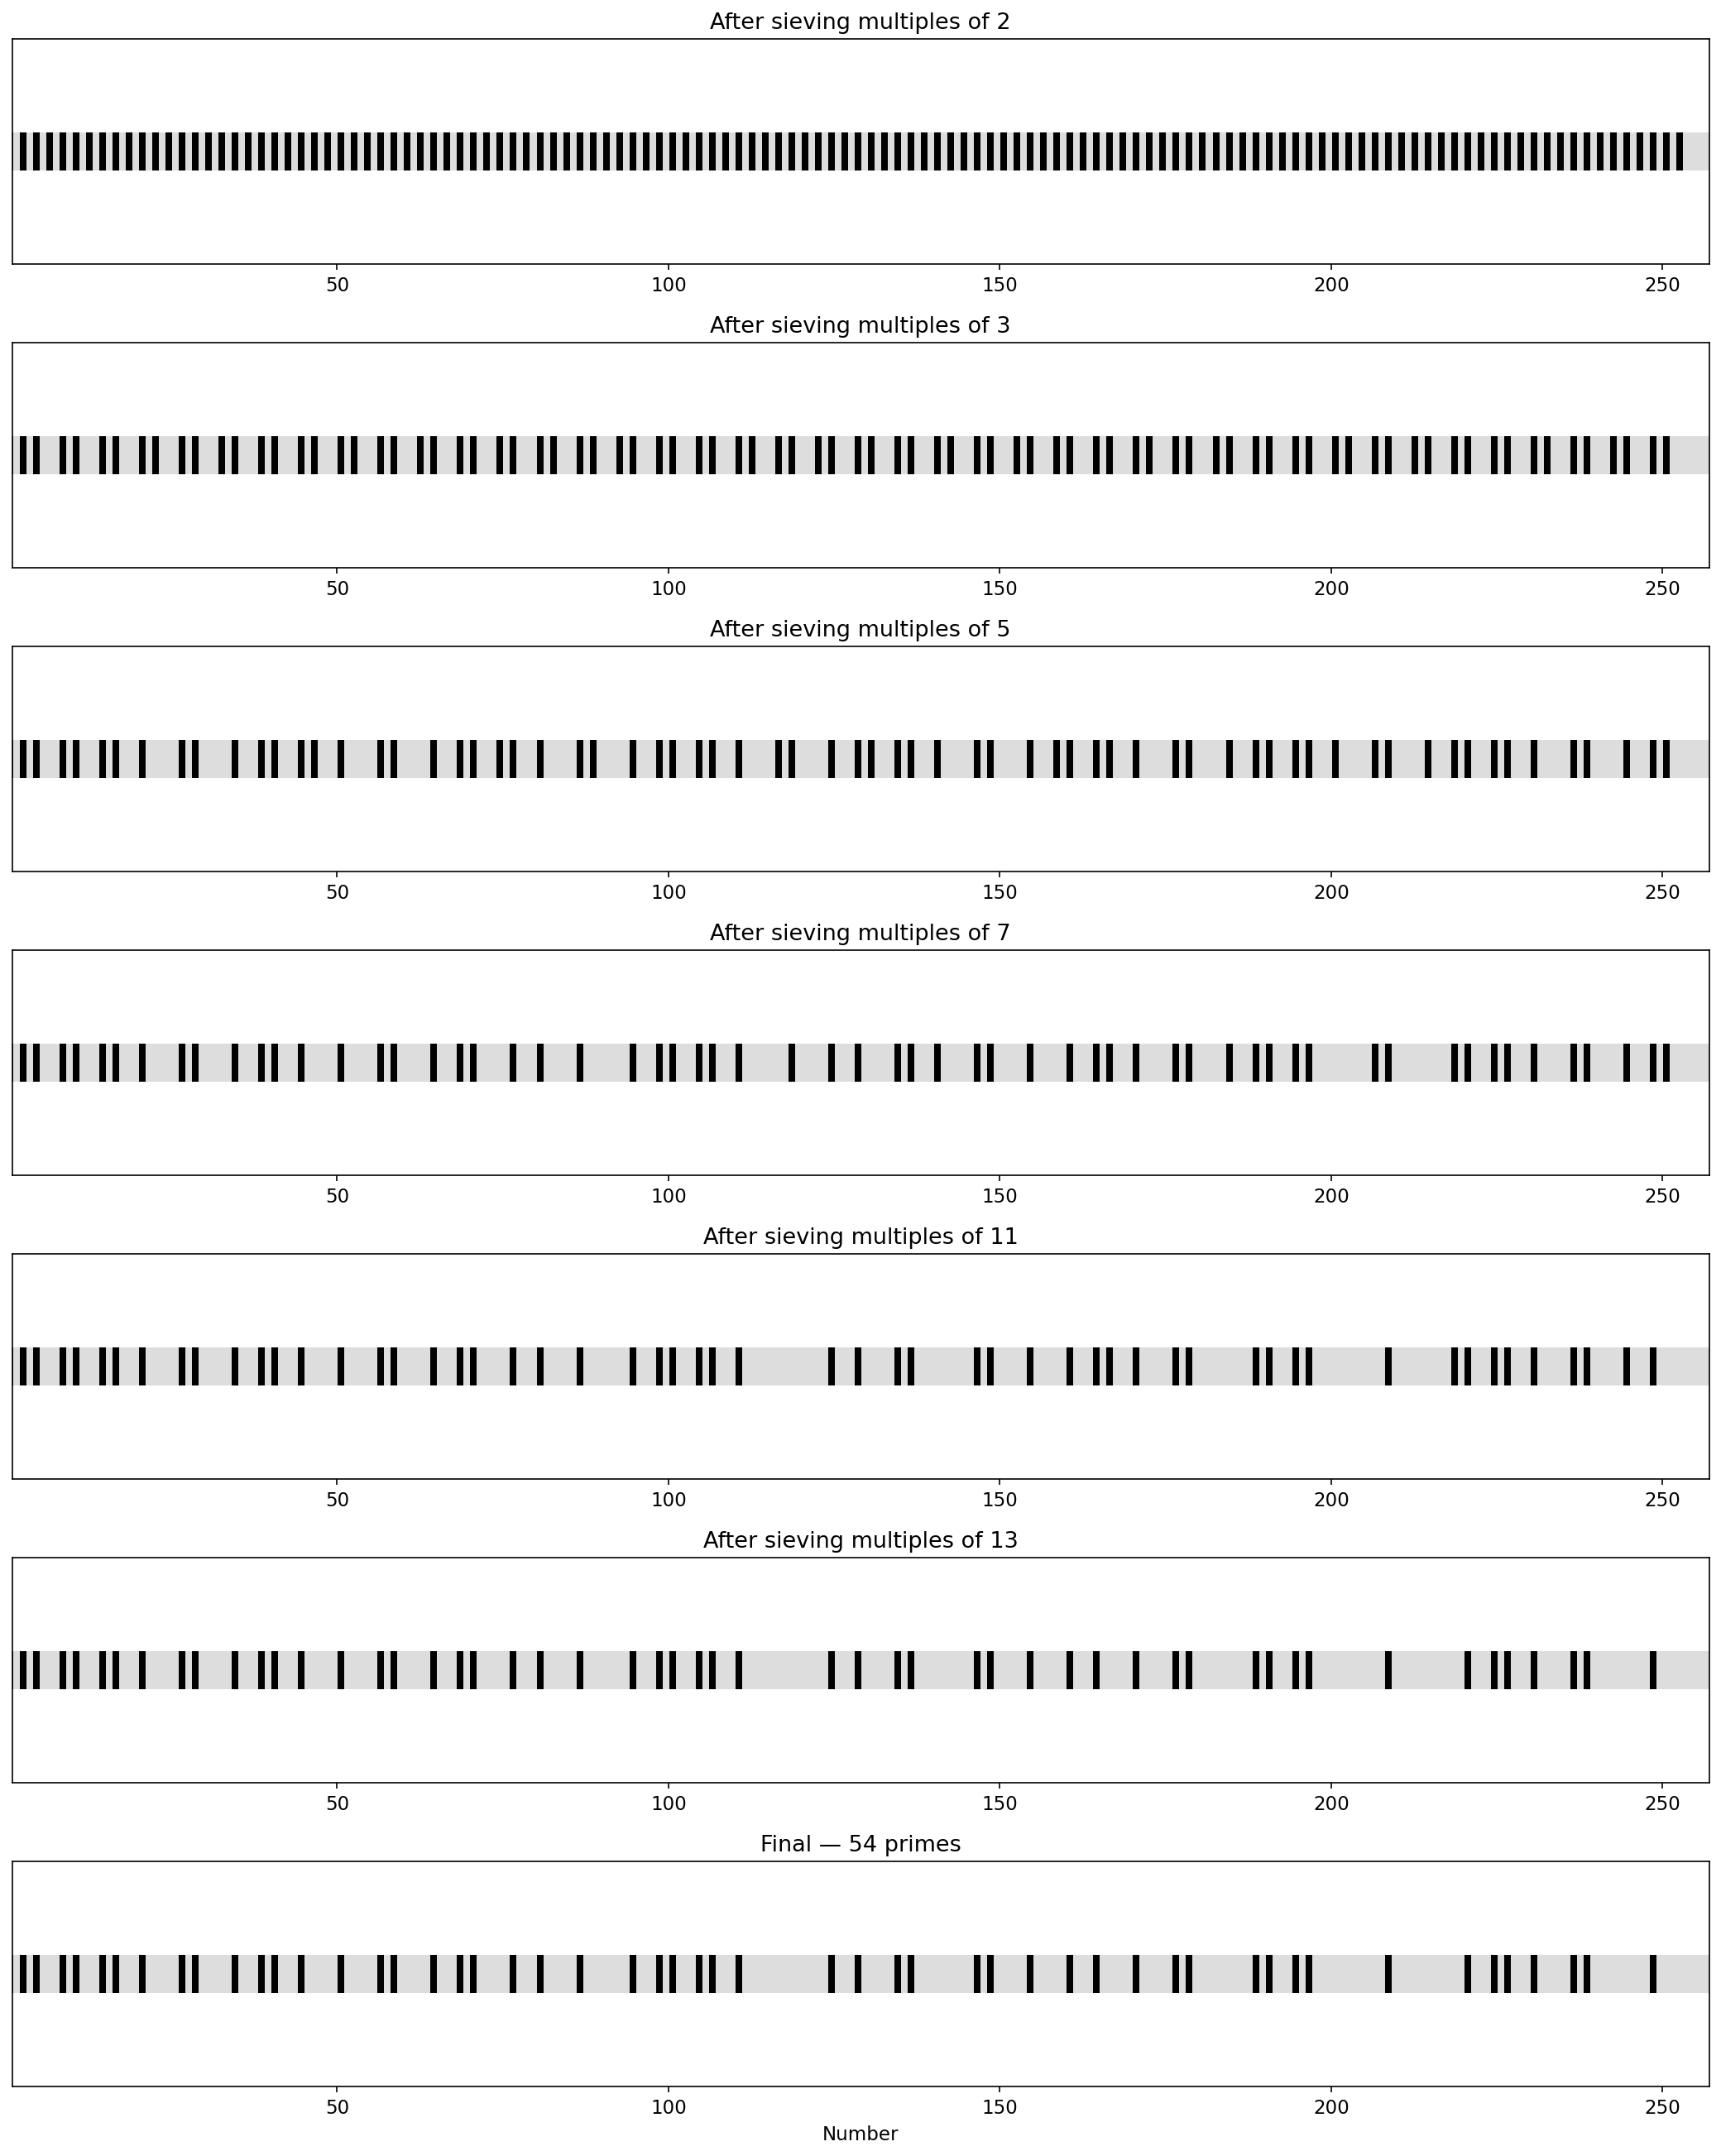

Snapshots taken at primes: [2, 3, 5, 7, 11, 13]


In [ ]:
def sieve_visual(limit):
    is_prime = np.ones(limit + 1, dtype=bool)
    is_prime[:2] = False
    
    snapshots = {}
    for p in range(2, int(limit**0.5) + 1):
        if is_prime[p]:
            is_prime[p*p : limit+1 : p] = False
            snapshots[p] = is_prime.copy()
    snapshots['final'] = is_prime.copy()
    
    n_snaps = len(snapshots)
    _, axes = plt.subplots(n_snaps, 1, figsize=(14, 2.5 * n_snaps))
    for ax, (label, state) in zip(axes, snapshots.items()):
        colors = ['black' if state[i] else '#dddddd' for i in range(2, limit+1)]
        ax.scatter(range(2, limit+1), [1]*(limit-1), c=colors, s=500, marker='s', edgecolors='none')
        ax.set_xlim(1, limit+1)
        ax.set_ylim(0.5, 1.5)
        ax.set_yticks([])
        
        if label == 'final':
            ax.set_title(f'Final — {sum(state)} primes')
            ax.set_xlabel('Number')
        else:
            ax.set_title(f'After sieving multiples of {label}')
    plt.tight_layout()
    plt.savefig('sieve_visual.png', bbox_inches='tight')
    plt.show()
    print(f"Snapshots taken at primes: {[k for k in snapshots if k != 'final']}")

limit = 256
sieve_visual(limit)

## The Prime Number Theorem

The PNT states that the number of primes ≤ $x$ is approximately:

$$\pi(x) \sim \frac{x}{\ln x}$$

Equivalently, the *density* of primes near $x$ is about $1/\ln(x)$. As numbers get larger, primes thin out predictably.

This can be verified empirically using the parallel sieve engine.

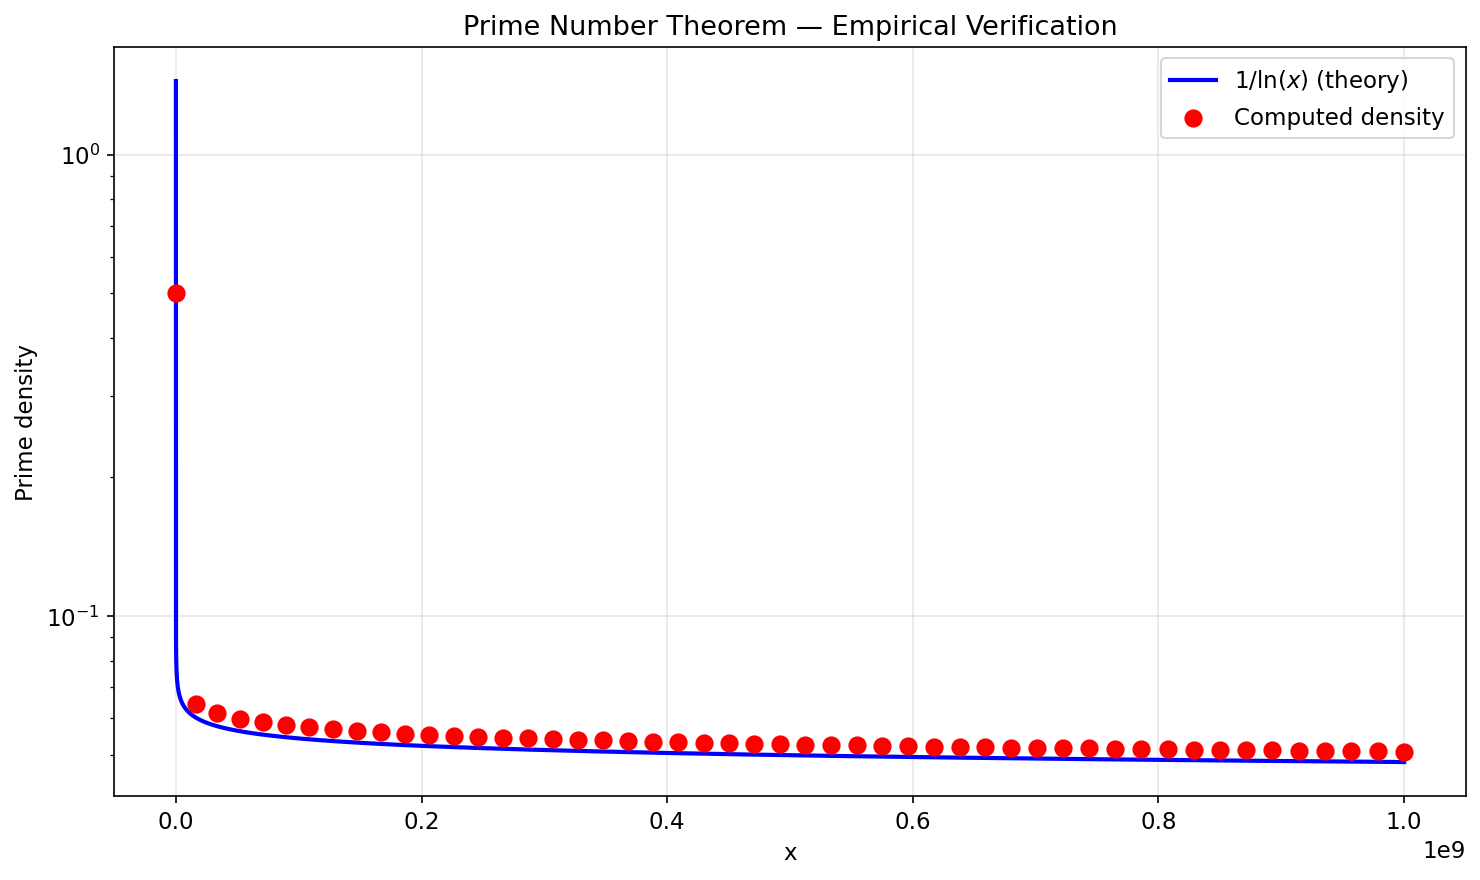

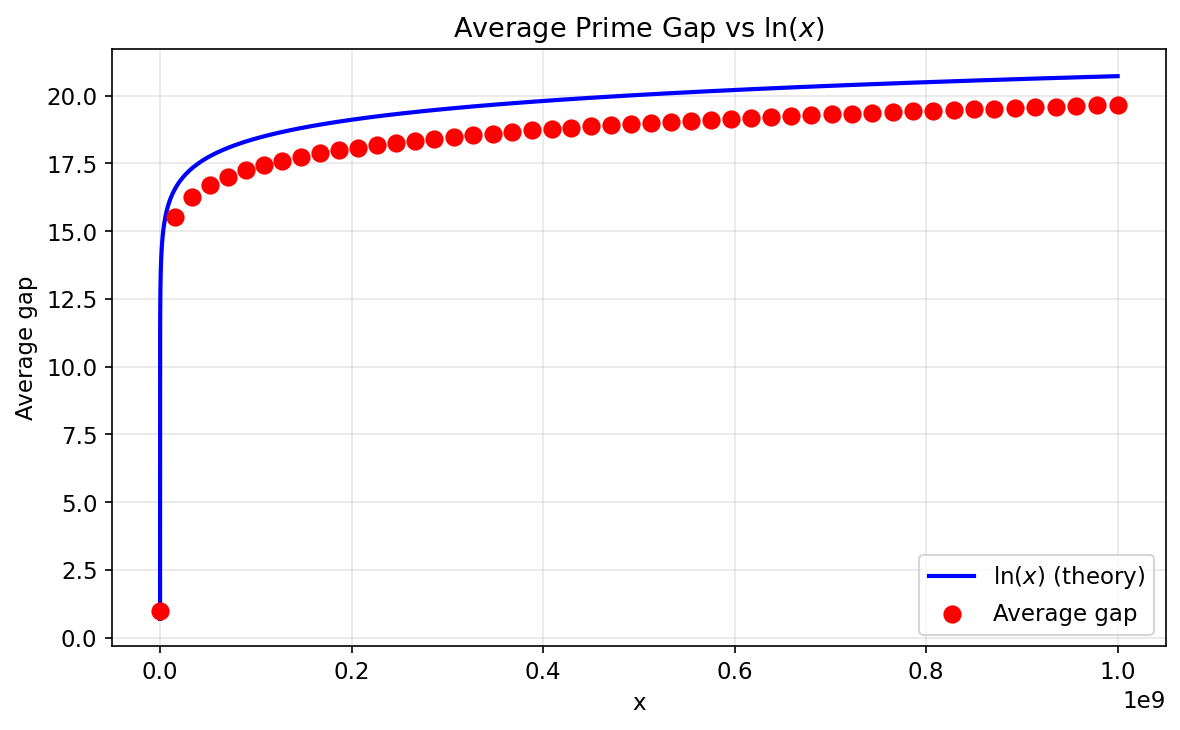

In [49]:
def plot_pnt(primes, num_points):
    indices = np.linspace(0, len(primes) - 1, num_points, dtype=int)
    x_vals = primes[indices]
    densities = (indices + 1) / x_vals

    x_smooth = np.logspace(np.log10(primes[0]), np.log10(primes[-1]), 500)
    theory = 1 / np.log(x_smooth)

    _, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_smooth, theory, "b-", linewidth=2, label=r"$1/\ln(x)$ (theory)")
    ax.scatter(x_vals, densities, c="red", s=60, zorder=5, label="Computed density")

    ax.set_xlabel("x")
    ax.set_ylabel("Prime density")
    ax.set_title("Prime Number Theorem — Empirical Verification")
    ax.legend()
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("pnt_density.png", bbox_inches="tight")
    plt.show()


def plot_average_gap(primes, num_points):
    indices = np.linspace(0, len(primes) - 2, num_points, dtype=int)
    x_vals = primes[indices]
    avg_gaps = [np.mean(np.diff(primes[: i + 2])) for i in indices]

    x_smooth = np.logspace(np.log10(primes[0]), np.log10(primes[-1]), 500)
    theory = np.log(x_smooth)

    _, ax = plt.subplots()
    ax.plot(x_smooth, theory, "b-", linewidth=2, label=r"$\ln(x)$ (theory)")
    ax.scatter(x_vals, avg_gaps, c="red", s=60, zorder=5, label="Average gap")

    ax.set_xlabel("x")
    ax.set_ylabel("Average gap")
    ax.set_title(r"Average Prime Gap vs $\ln(x)$")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("pnt_gaps.png", bbox_inches="tight")
    plt.show()


num_points = 50

plot_pnt(primes, num_points)
plot_average_gap(primes, num_points)

## Prime Gaps

The difference between consecutive primes, $g_n = p_{n+1} - p_n$, is called a prime gap. 
Most gaps are small (2, 4, 6, ...), but occasionally large gaps appear. 
Gaps of size 2 are called *twin primes*, which is conjectured there are infinitely many, 
but this remains unproven.

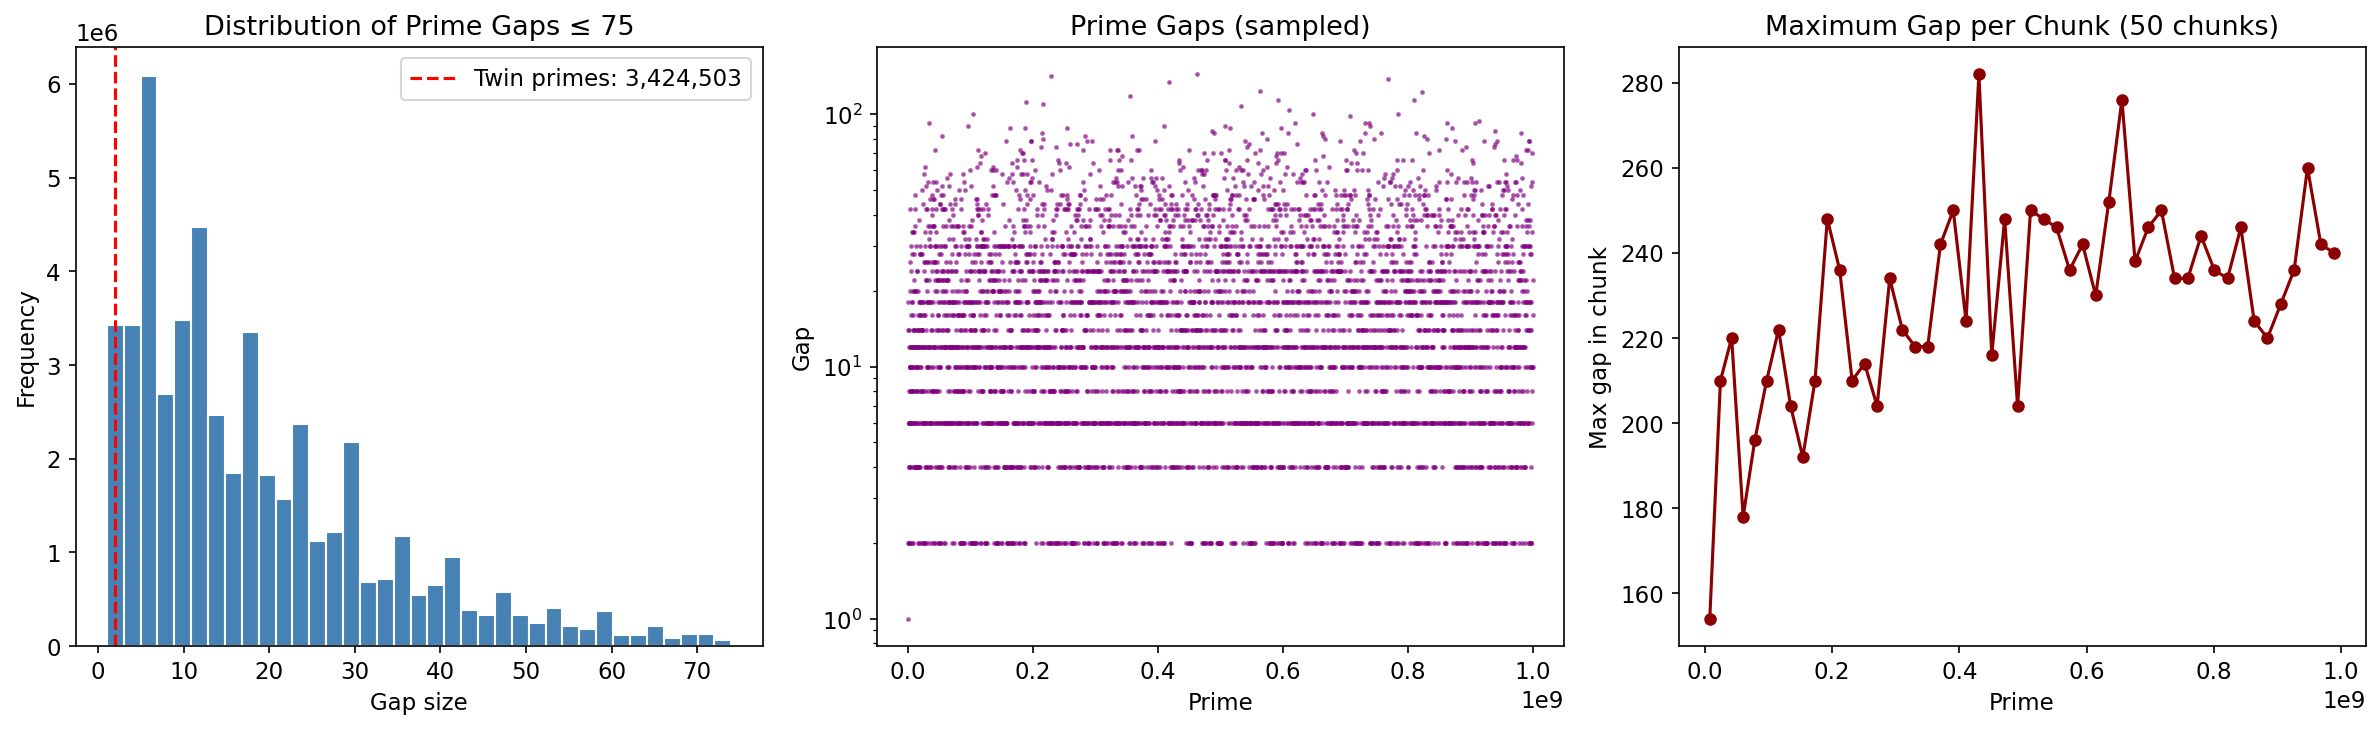

Total gaps analyzed: 50,847,524
Twin primes found: 3,424,503 (6.73% of gaps)
Largest gap: 282
Average gap: 19.67


In [26]:
def plot_gaps(primes, max_gap_display=100, num_chunks=20):
    gaps = np.diff(primes)
    twin_count = np.sum(gaps == 2)

    _, axes = plt.subplots(1, 3, figsize=(16, 5))

    small_gaps = gaps[gaps <= max_gap_display]
    bins = min(max_gap_display // 2, 50)
    axes[0].hist(small_gaps, bins=bins, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Gap size")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title(f"Distribution of Prime Gaps ≤ {max_gap_display}")
    axes[0].axvline(
        2, color="red", linestyle="--", label=f"Twin primes: {twin_count:,}"
    )
    axes[0].legend()

    step = max(len(primes) // 5000, 1)
    sample = primes[1:][::step]
    sample_gaps = gaps[::step]
    axes[1].scatter(sample, sample_gaps, s=2, alpha=0.5, color="purple")
    axes[1].set_xlabel("Prime")
    axes[1].set_ylabel("Gap")
    axes[1].set_yscale('log')
    axes[1].set_title("Prime Gaps (sampled)")

    chunk_size = len(gaps) // num_chunks
    max_gaps = [
        np.max(gaps[i * chunk_size : (i + 1) * chunk_size]) for i in range(num_chunks)
    ]
    chunk_centers = primes[
        np.arange(chunk_size // 2, len(primes) - chunk_size // 2, chunk_size)[
            :num_chunks
        ]
    ]
    axes[2].plot(chunk_centers, max_gaps, "o-", color="darkred", markersize=5)
    axes[2].set_xlabel("Prime")
    axes[2].set_ylabel("Max gap in chunk")
    axes[2].set_title(f"Maximum Gap per Chunk ({num_chunks} chunks)")

    plt.tight_layout()
    plt.savefig("prime_gaps.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Total gaps analyzed: {len(gaps):,}")
    print(
        f"Twin primes found: {twin_count:,} ({100.0 * twin_count / len(gaps):.2f}% of gaps)"
    )
    print(f"Largest gap: {np.max(gaps)}")
    print(f"Average gap: {np.mean(gaps):.2f}")


max_gap_display = 75
num_chunks = 50
plot_gaps(primes, max_gap_display, num_chunks)

## Parallelism: Processes vs Threads

The C engine can distribute work across multiple processes (via `fork()`) 
and multiple threads per process (via `pthreads`). 

Relevant questions:
* How does wall-clock time scale with more workers?
* Where is the sweet spot before overhead dominates?
* Why do processes scale better than threads for CPU-bound work?

**Key insight:** Processes have separate memory spaces and avoid contention. 
Threads share memory and compete for caches and locks, creating diminishing returns.

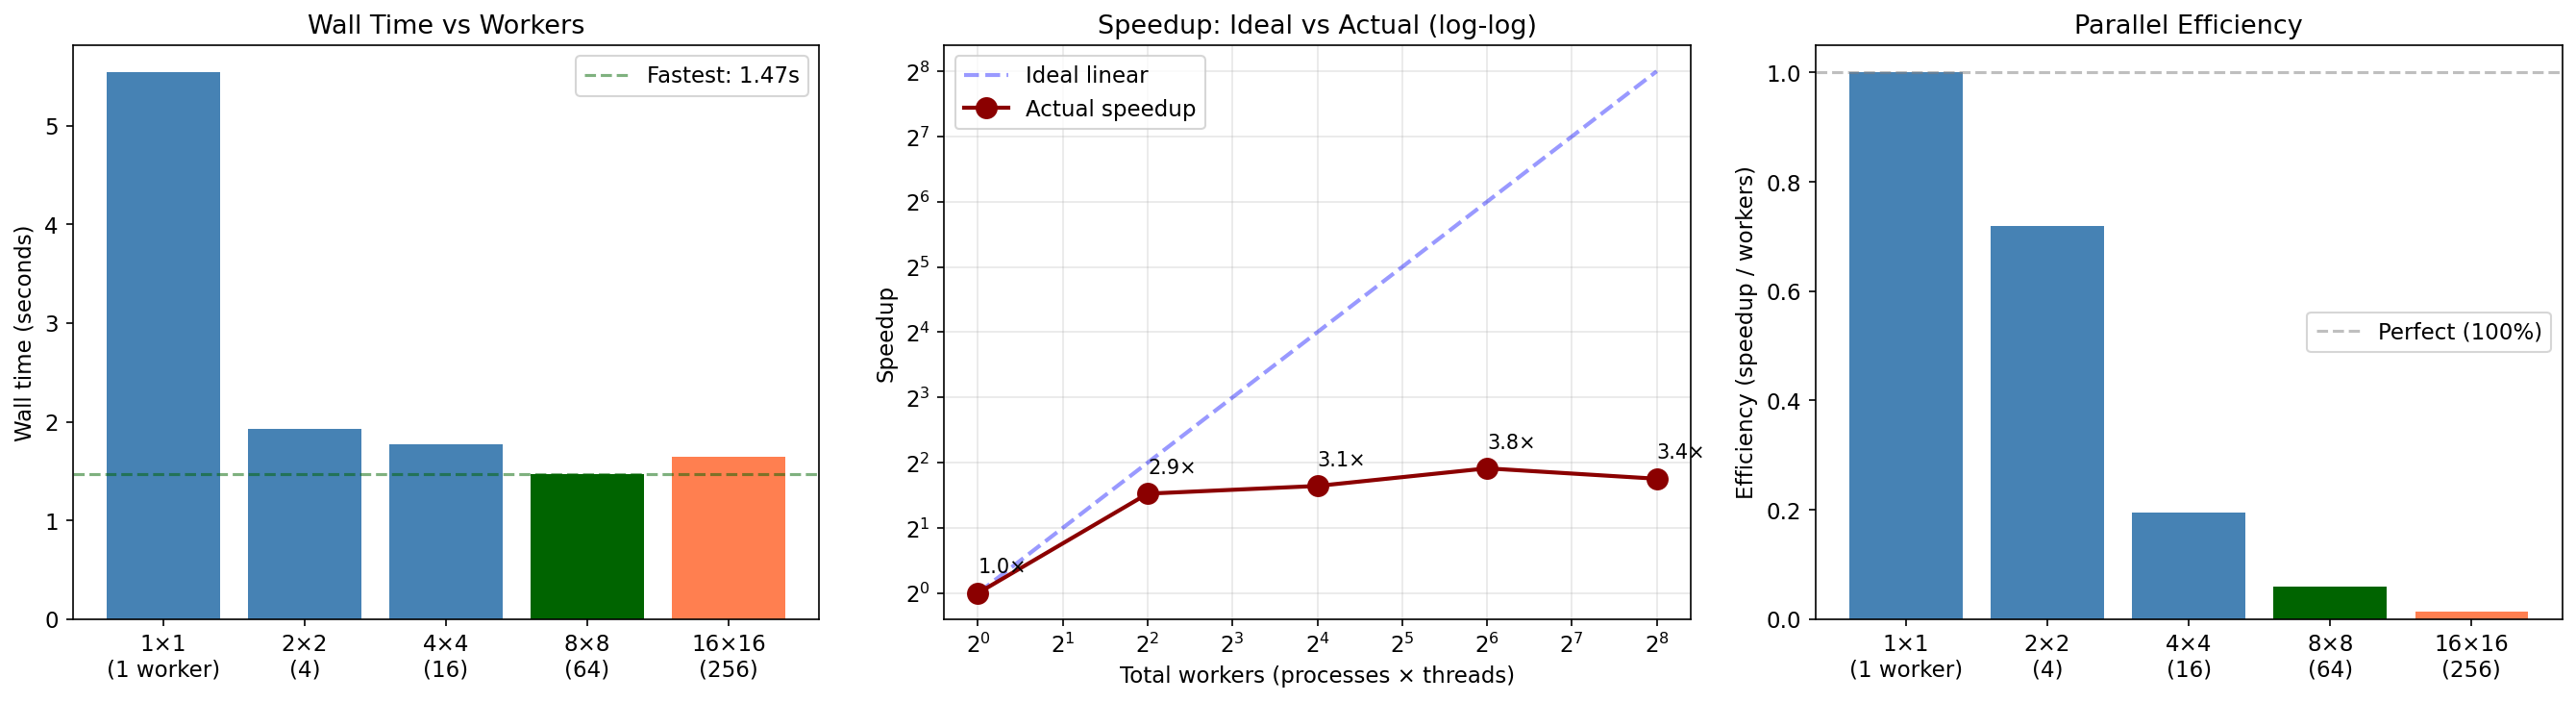

Key findings:
  Best wall time: 1.47s at 8×8 (64 workers)
  Worst scaling: 16×16 is 1.1× slower than 8×8 despite 4× more workers
  User time at 16×16 (9.1s) > single-thread (5.2s) → overhead dominates


In [ ]:
configs = ['1×1\n(1 worker)', '2×2\n(4)', '4×4\n(16)', '8×8\n(64)', '16×16\n(256)']
wall_times = [5.539, 1.925, 1.774, 1.471, 1.643] # precomputed wall times using benchmarks.sh
user_times = [5.215, 6.550, 9.655, 7.913, 9.128] # precomputed user times using benchmarks.sh
speedup = [1.0, 5.539/1.925, 5.539/1.774, 5.539/1.471, 5.539/1.643]
efficiency = [s / w for s, w in zip(speedup, [1, 4, 16, 64, 256])]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(configs, wall_times, color=['steelblue', 'steelblue', 'steelblue', 'darkgreen', 'coral'])
axes[0].set_ylabel('Wall time (seconds)')
axes[0].set_title('Wall Time vs Workers')
axes[0].axhline(y=wall_times[3], color='darkgreen', linestyle='--', alpha=0.5, label=f'Fastest: {wall_times[3]:.2f}s')
axes[0].legend()

workers = [1, 4, 16, 64, 256]
axes[1].plot(workers, workers, 'b--', alpha=0.4, linewidth=2, label='Ideal linear')
axes[1].plot(workers, speedup, 'o-', color='darkred', linewidth=2, markersize=10, label='Actual speedup')
axes[1].set_xlabel('Total workers (processes × threads)')
axes[1].set_ylabel('Speedup')
axes[1].set_title('Speedup: Ideal vs Actual (log-log)')
axes[1].set_xscale('log', base=2)
axes[1].set_yscale('log', base=2)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
for w, s in zip(workers, speedup):
    axes[1].annotate(f'{s:.1f}×', (w, s), textcoords="offset points", xytext=(0, 10), fontsize=10)

axes[2].bar(configs, efficiency, color=['steelblue', 'steelblue', 'steelblue', 'darkgreen', 'coral'])
axes[2].set_ylabel('Efficiency (speedup / workers)')
axes[2].set_title('Parallel Efficiency')
axes[2].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Perfect (100%)')
axes[2].legend()

plt.tight_layout()
plt.savefig('parallel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key findings:")
print(f"  Best wall time: {min(wall_times):.2f}s at 8×8 (64 workers)")
print(f"  Worst scaling: 16×16 is {wall_times[-1]/wall_times[3]:.1f}× slower than 8×8 despite 4× more workers")
print(f"  User time at 16×16 ({user_times[-1]:.1f}s) > single-thread ({user_times[0]:.1f}s) → overhead dominates")

## Why Processes Outperform Threads Here

Our data shows that wall time decreases from ~5.5s (1 worker) to ~1.5s (64 workers), 
but then *increases* to ~1.6s with 256 workers. Why?

| Feature | Processes (`fork()`) | Threads (`pthreads`) |
|---------|---------------------|----------------------|
| Memory | Separate address spaces | Shared memory |
| Communication | No shared state (by default) | Shared caches → contention |
| Overhead | Higher creation cost | Lower creation cost |
| Scaling | Linear for embarrassingly parallel work | Bottlenecked by cache misses |

In the prime sieve, each worker operates on an independent segment of the number line 
with zero communication, the textbook case for **process-level parallelism**. 
Threads within each process add little benefit because the primesieve library 
already saturates the CPU's arithmetic units, making memory bandwidth the true bottleneck.

**The sweet spot at 8×8 represents the point where CPU utilization is maximized 
before process creation overhead and memory contention outweigh the benefits of 
further subdivision.**

## The Ulam Spiral

In 1963, mathematician Stanisław Ulam doodled a number spiral during a boring lecture 
and noticed something striking: primes cluster along diagonal lines.

Write the natural numbers in a square spiral:

$$\begin{matrix} 
37 & 36 & 35 & 34 & 33 & 32 & 31 \\
38 & 17 & 16 & 15 & 14 & 13 & 30 \\
39 & 18 & 5  & 4  & 3  & 12 & 29 \\
40 & 19 & 6  & 1  & 2  & 11 & 28 \\
41 & 20 & 7  & 8  & 9  & 10 & 27 \\
42 & 21 & 22 & 23 & 24 & 25 & 26 \\
43 & 44 & 45 & 46 & 47 & 48 & 49
\end{matrix}$$

If you mark the primes then diagonal streaks start to appear, and these 
correspond to quadratic polynomials like Euler's $n^2 + n + 41$, 
which produces primes for $n = 0$ through 39. 

No one fully understands why certain quadratics generate so many primes. 
The Ulam spiral remains one of mathematics' beautiful open mysteries.

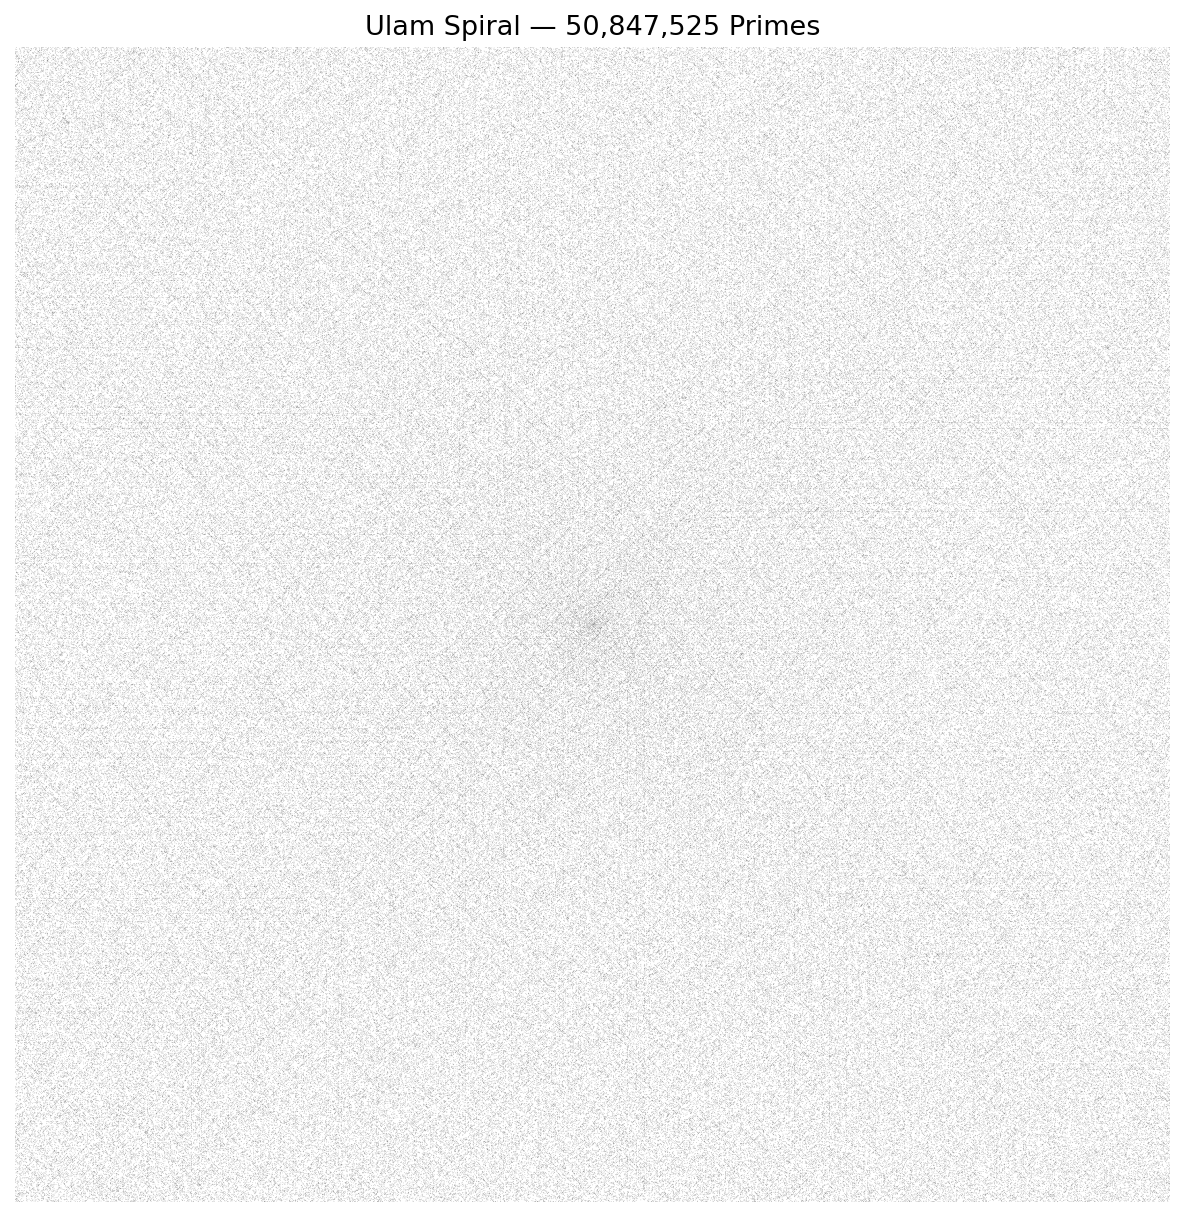

In [28]:
pp.plot_ulam_datashader(primes)

[Click here to open full-resolution Ulam Spiral](ulam_spiral.png)